In [ ]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

def main():
    print("--- DÉMARRAGE DU PIPELINE DE CLUSTERING (DYNAMIQUE + ACP) ---")

    # 1. Configuration des chemins
    input_path = '../data/train_test/X_train.csv'
    model_dir = '../models/'
    os.makedirs(model_dir, exist_ok=True)

    # 2. Chargement des données (Correction du séparateur)
    try:
        # On utilise sep=None pour laisser pandas détecter si c'est ',' ou ';'
        df = pd.read_csv(input_path, sep=None, engine='python')
        print(f"Chargement réussi. Colonnes détectées : {len(df.columns)}")
    except Exception as e:
        print(f"ERREUR LECTURE : {e}")
        return

    # 3. Sélection Dynamique des Variables
    # On prend tout ce qui est numérique
    X_cluster = df.select_dtypes(include=[np.number]).copy()
    
    # Sécurité : on retire l'ID ou l'index s'ils sont présents
    to_exclude = ['CustomerID', 'id', 'index', 'Unnamed: 0']
    X_cluster = X_cluster.drop(columns=[c for c in to_exclude if c in X_cluster.columns])

    if X_cluster.empty:
        print("ERREUR : Aucune donnée numérique trouvée. Vérifie le format de ton CSV.")
        print("Dtypes actuels :", df.dtypes)
        return

    print(f"Variables utilisées pour l'ACP : {list(X_cluster.columns)}")

    # 4. Standardisation
    scaler_km = StandardScaler()
    X_scaled = scaler_km.fit_transform(X_cluster)

    # 5. Application de l'ACP (95% de variance)
    pca_model = PCA(n_components=0.95, random_state=42)
    X_pca = pca_model.fit_transform(X_scaled)
    print(f"ACP : de {X_cluster.shape[1]} à {X_pca.shape[1]} composantes.")

    # 6. Clustering K-Means
    K_CHOISI = 4
    kmeans_final = KMeans(n_clusters=K_CHOISI, random_state=42, n_init=10)
    df['Cluster'] = kmeans_final.fit_predict(X_pca)

    # 7. Sauvegarde des modèles
    joblib.dump(scaler_km, os.path.join(model_dir, 'scaler_kmeans.pkl'))
    joblib.dump(pca_model, os.path.join(model_dir, 'pca_model.pkl'))
    joblib.dump(kmeans_final, os.path.join(model_dir, 'kmeans_model.pkl'))

    # 8. Profilage (Dynamique également)
    # On calcule la moyenne de chaque cluster pour toutes les variables numériques
    cluster_profiles = df.groupby('Cluster')[X_cluster.columns].mean()
    cluster_profiles.to_csv(os.path.join(model_dir, 'cluster_profiles.csv'))

    print("\n--- PROFILS DES CLUSTERS (MOYENNES) ---")
    print(cluster_profiles.round(2))
    print("\nRépartition :")
    print(df['Cluster'].value_counts())

if __name__ == "__main__":
    main()

--- DÉMARRAGE DU PIPELINE DE CLUSTERING (DYNAMIQUE + ACP) ---
Chargement réussi. Colonnes détectées : 45
Variables utilisées pour l'ACP : ['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'AvgQuantityPerTransaction', 'PreferredDayOfWeek', 'PreferredHour', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'ReturnRatio', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'AgeCategory', 'SpendingCategory', 'LoyaltyLevel', 'BasketSizeCategory', 'Country', 'RegDay', 'RegWeekday', 'IP_IsPrivate', 'IP_FirstOctet', 'AvgBasketValue', 'Gender_F', 'Gender_M', 'Gender_Unknown', 'ProductDiversity_Explorateur', 'ProductDiversity_Spécialisé', 'Region_Afrique', 'Region_Amérique du Nord', 'Region_Amérique du Sud', 'Region_Asie', 'Region_Autre', 'Region_Europe centrale', 'Region_Europe continentale', "Region_Europe de l'Est", 'Region_Europe du Nord', 'Region_Europe du Sud', 'Region_Mo

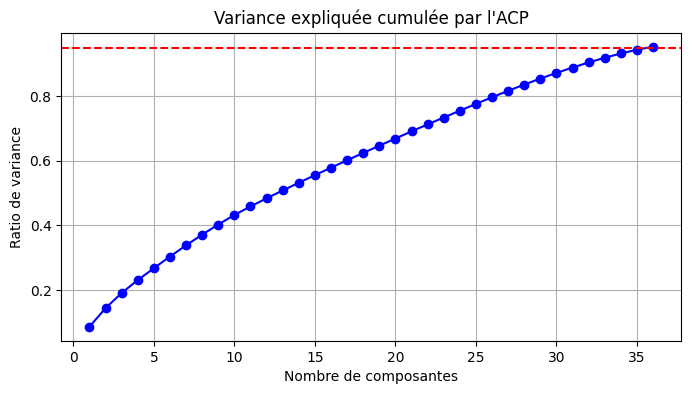

Nombre de composantes pour atteindre 95% : 36


In [ ]:
import matplotlib.pyplot as plt
# Chargement de l'objet PCA sauvegardé
pca_model = joblib.load('../models/pca_model.pkl')

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca_model.explained_variance_ratio_) + 1), 
         np.cumsum(pca_model.explained_variance_ratio_), 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.title("Variance expliquée cumulée par l'ACP")
plt.xlabel("Nombre de composantes")
plt.ylabel("Ratio de variance")
plt.grid(True)
plt.show()

print(f"Nombre de composantes pour atteindre 95% : {pca_model.n_components_}")

Colonnes envoyées au scaler : ['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'AvgQuantityPerTransaction', 'PreferredDayOfWeek', 'PreferredHour', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'ReturnRatio', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'AgeCategory', 'SpendingCategory', 'LoyaltyLevel', 'BasketSizeCategory', 'Country', 'RegDay', 'RegWeekday', 'IP_IsPrivate', 'IP_FirstOctet', 'AvgBasketValue', 'Gender_F', 'Gender_M', 'Gender_Unknown', 'ProductDiversity_Explorateur', 'ProductDiversity_Spécialisé', 'Region_Afrique', 'Region_Amérique du Nord', 'Region_Amérique du Sud', 'Region_Asie', 'Region_Autre', 'Region_Europe centrale', 'Region_Europe continentale', "Region_Europe de l'Est", 'Region_Europe du Nord', 'Region_Europe du Sud', 'Region_Moyen-Orient', 'Region_Océanie']


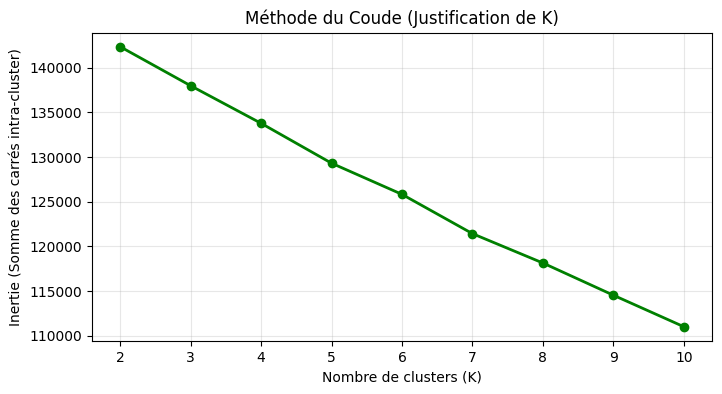

In [7]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Chargement ROBUSTE (identique au script)
input_path = '../data/train_test/X_train.csv'
df_test = pd.read_csv(input_path, sep=None, engine='python')

# 2. Sélection DYNAMIQUE des colonnes (identique au script)
# On prend les numériques et on exclut les IDs/Target
X_cluster = df_test.select_dtypes(include=[np.number]).copy()
to_exclude = ['CustomerID', 'id', 'index', 'Unnamed: 0', 'Churn']
X_cluster = X_cluster.drop(columns=[c for c in to_exclude if c in X_cluster.columns])

print(f"Colonnes envoyées au scaler : {list(X_cluster.columns)}")

# 3. Application de la chaîne de transformation
try:
    scaler = joblib.load('../models/scaler_kmeans.pkl')
    pca = joblib.load('../models/pca_model.pkl')
    
    # Transformation
    X_scaled = scaler.transform(X_cluster)
    X_test_pca = pca.transform(X_scaled)
    
    # 4. Calcul de l'inertie pour le coude
    inertias = []
    k_range = range(2, 11)
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_test_pca)
        inertias.append(km.inertia_)

    # 5. Graphique
    plt.figure(figsize=(8, 4))
    plt.plot(k_range, inertias, 'go-', linewidth=2)
    plt.title("Méthode du Coude (Justification de K)")
    plt.xlabel("Nombre de clusters (K)")
    plt.ylabel("Inertie (Somme des carrés intra-cluster)")
    plt.grid(True, alpha=0.3)
    plt.show()

except Exception as e:
    print(f"ERREUR : {e}")

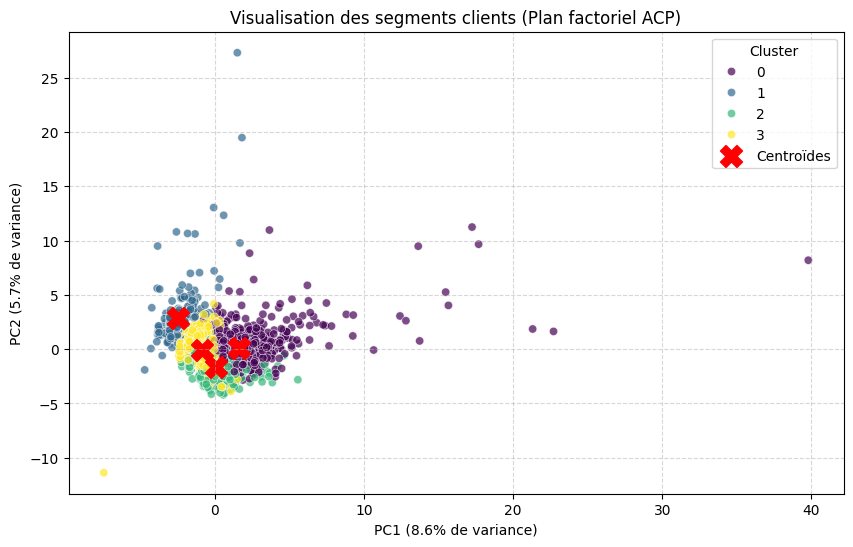

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import numpy as np

# 1. Chargement des artefacts et des données
try:
    kmeans = joblib.load('../models/kmeans_model.pkl')
    pca = joblib.load('../models/pca_model.pkl')
    scaler = joblib.load('../models/scaler_kmeans.pkl')
    
    # Recharger les données pour s'assurer que X_test_pca existe dans cette cellule
    df_test = pd.read_csv('../data/train_test/X_train.csv', sep=None, engine='python')
    X_cluster = df_test.select_dtypes(include=[np.number]).copy()
    X_cluster = X_cluster.drop(columns=[c for c in ['CustomerID', 'Churn', 'index'] if c in X_cluster.columns])
    
    # Transformation
    X_test_pca = pca.transform(scaler.transform(X_cluster))
    
    # Prédire les labels (plus sûr que d'utiliser kmeans.labels_ si on a rechargé les données)
    labels = kmeans.predict(X_test_pca)

    # 2. Visualisation
    plt.figure(figsize=(10, 6))
    
    # On utilise les deux premières composantes de l'ACP (Index 0 et 1)
    sns.scatterplot(
        x=X_test_pca[:, 0], 
        y=X_test_pca[:, 1], 
        hue=labels, 
        palette='viridis', 
        alpha=0.7, 
        edgecolor='w'
    )
    
    # Affichage des centres de clusters (Centroïdes)
    plt.scatter(
        kmeans.cluster_centers_[:, 0], 
        kmeans.cluster_centers_[:, 1], 
        s=250, 
        c='red', 
        marker='X', 
        label='Centroïdes'
    )

    plt.title("Visualisation des segments clients (Plan factoriel ACP)")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de variance)")
    plt.legend(title="Cluster")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

except FileNotFoundError:
    print("Erreur : Assurez-vous d'avoir exécuté le script clustering.py pour générer les modèles dans ../models/")

In [10]:
profile_path = '../models/cluster_profiles.csv'
if os.path.exists(profile_path):
    df_profiles = pd.read_csv(profile_path)
    print("--- Vérification des profils de clusters ---")
    display(df_profiles)
else:
    print("Erreur : Le fichier de profilage n'a pas été généré.")

--- Vérification des profils de clusters ---


,Cluster,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,AvgQuantityPerTransaction,PreferredDayOfWeek,PreferredHour,WeekendPurchaseRatio,AvgDaysBetweenPurchases,...,Region_Amérique du Sud,Region_Asie,Region_Autre,Region_Europe centrale,Region_Europe continentale,Region_Europe de l'Est,Region_Europe du Nord,Region_Europe du Sud,Region_Moyen-Orient,Region_Océanie
0,0,0.543336,0.328578,0.009122,-0.023103,-0.006424,-0.236923,-0.116845,-0.234915,-0.038985,...,0.000000,0.002449,0.005714,0.004082,0.099592,0.000000,0.017143,0.006531,0.001633,0.004082
1,1,-0.351444,-0.203366,0.780876,0.366112,0.750511,-0.133060,-0.118246,-0.287297,0.872549,...,0.000000,0.012346,0.000000,0.000000,0.032922,0.000000,0.000000,0.000000,0.000000,0.000000
2,2,-0.150899,-0.115231,-0.105568,-0.030468,-0.104533,1.873548,0.208145,2.397011,-0.125092,...,0.002358,0.002358,0.000000,0.000000,0.033019,0.002358,0.000000,0.000000,0.000000,0.000000
3,3,-0.321623,-0.189552,-0.097300,-0.029748,-0.081111,-0.293969,0.052096,-0.410435,-0.069304,...,0.000000,0.000623,0.000623,0.004984,0.054829,0.000000,0.006854,0.009346,0.002492,0.001246
